# 04 `fpos` Model Progression

This notebook is the main positive result of the thesis. It reconstructs the `fpos` path from weak transfer baselines to the final waveform-enhanced, trust-aware, family-balanced winner.

**Questions answered here**
- How much does each modeling wave improve over the simple transfer baseline?
- Which ablation blocks mattered most?
- Were the gains broad across recordings and families, or concentrated in a few easy regimes?


In [1]:
from pathlib import Path
import sys
import json

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

def _find_thesis_root():
    cwd = Path.cwd().resolve()
    direct = [cwd, *cwd.parents]
    nested = [candidate / "thesis" for candidate in direct]
    for candidate in [*direct, *nested]:
        if (candidate / "THESIS_BLUEPRINT.md").exists() and (candidate / "src" / "qc_thesis" / "__init__.py").exists():
            return candidate
    raise FileNotFoundError("Could not find thesis root from notebook session")

ROOT = _find_thesis_root()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from qc_thesis import *

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)
apply_thesis_style()

fig_dir, table_dir = notebook_output_dirs("04_fpos_model_progression")
benchmark = build_benchmark_progress_table("fpos")
ablation_winners = build_ablation_winner_table("fpos")
wave_ids = ["fpos_paired_context", "fpos_context_stack", "fpos_pre_waveform_unlabeled", "fpos_family_balanced", "fpos_waveform_winner"]
waves = build_main_wave_summary("fpos", wave_ids)
winner_diag = build_prediction_diagnostics("fpos_waveform_winner", "fpos")
limitations = get_limitations_bundle()


## 1. Benchmark ladder

The right baseline for the thesis is not the dummy model; it is the **basic hybrid+paired XGBoost transfer baseline**. Everything after that should be interpreted as an incremental answer to a specific scientific problem.


,label,mae,rmse,r2,bias,calibration_slope,delta_r2_vs_basic_transfer,delta_mae_vs_basic_transfer,notes
0,Dummy paired mean,0.191016,0.246455,-0.000221,-0.003661,0.000000,-0.358760,0.052308,Sanity floor
0,Paired-only raw,0.125948,0.176911,0.484615,-0.036165,1.002663,0.126076,-0.012761,Small paired baseline
0,Hybrid-only XGBoost,0.219198,0.295214,-0.435141,0.141308,0.461685,-0.793680,0.080490,Pure source failure baseline
0,Calibrated hybrid XGBoost,0.151354,0.214105,0.245126,-0.009120,1.090522,-0.113413,0.012646,Simple calibrated transfer
0,Hybrid+paired basic XGBoost,0.138708,0.197367,0.358539,0.058325,0.721856,0.000000,0.000000,Basic transfer baseline
0,Hybrid stack residual,0.142869,0.194832,0.374912,0.029187,0.774900,0.016373,0.004161,First nonlinear stack
0,Paired-only context,0.131280,0.179485,0.469508,-0.039368,1.043757,0.110968,-0.007429,Context-only target baseline
0,Context-first source stack,0.127567,0.174166,0.500484,-0.035463,1.060105,0.141945,-0.011142,Best pre-unlabeled context-first stack
0,Best SSL neural,0.276944,0.353444,-1.057136,0.194436,0.365486,-1.415675,0.138235,Best SSL comparison
0,Best MMD neural,0.150319,0.205458,0.304869,0.027606,0.712287,-0.053670,0.011611,Best MMD comparison


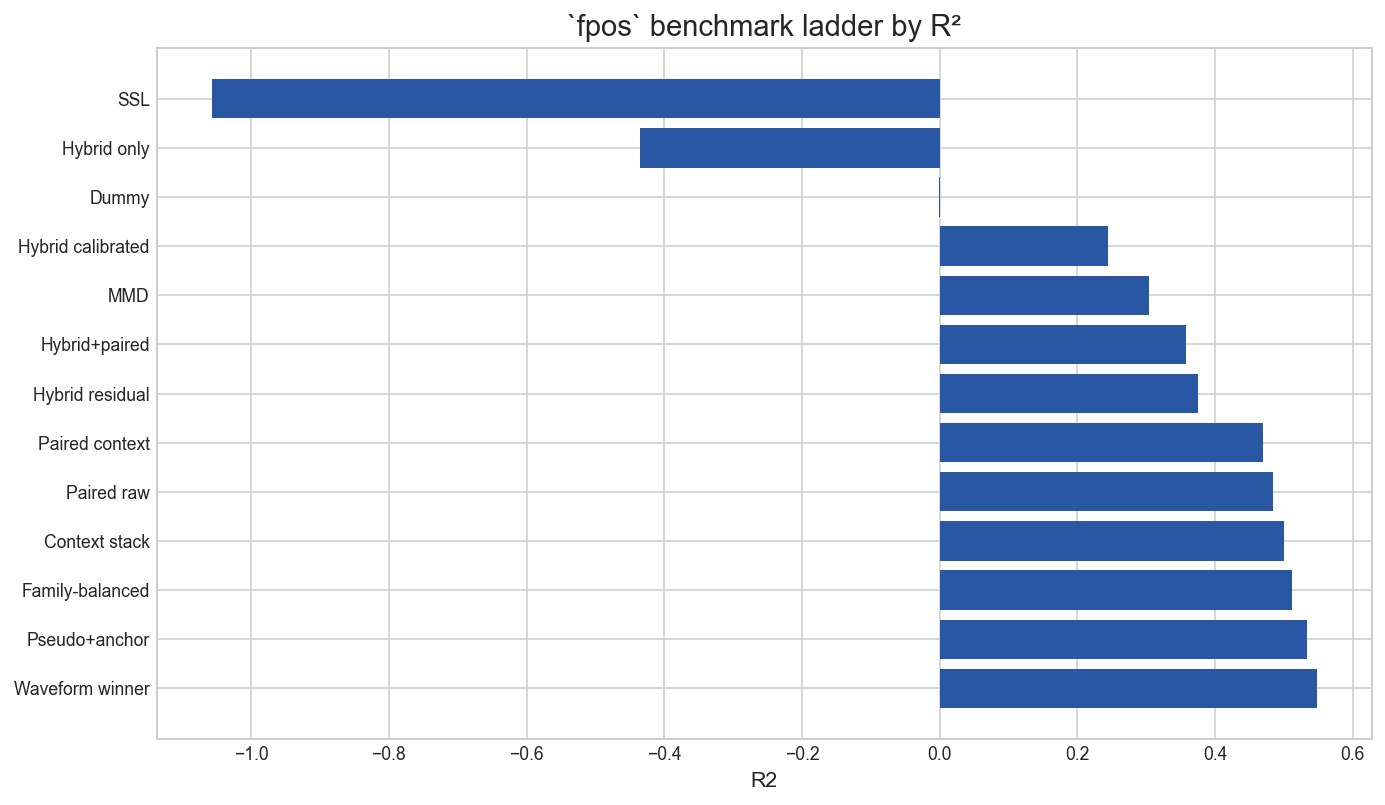

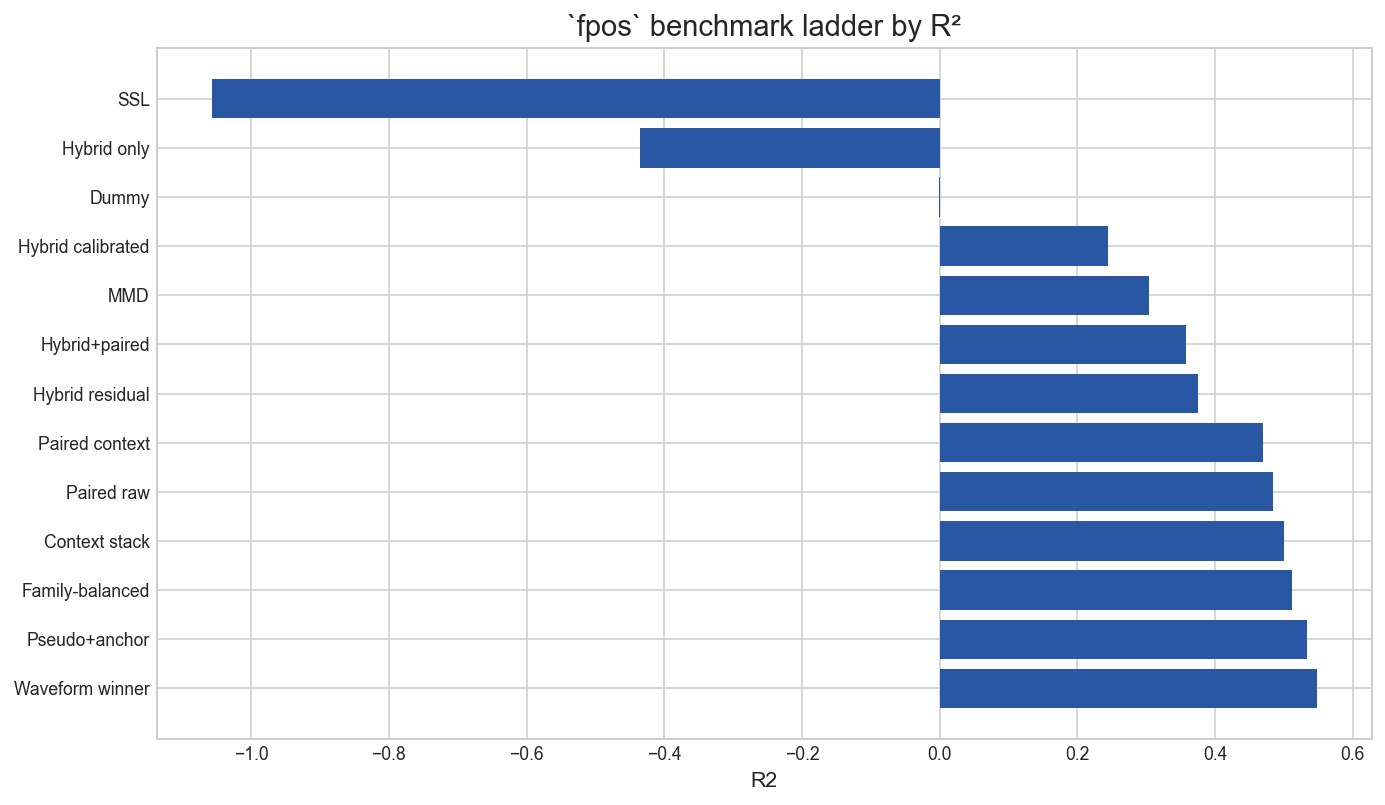

In [2]:
display(benchmark[["label", "mae", "rmse", "r2", "bias", "calibration_slope", "delta_r2_vs_basic_transfer", "delta_mae_vs_basic_transfer", "notes"]])
save_table(benchmark, table_dir, "fpos_benchmark_ladder")
fig, _ = plot_benchmark_metric(benchmark, metric="r2", title="`fpos` benchmark ladder by R²")
save_figure(fig, fig_dir, "fpos_benchmark_r2")
fig


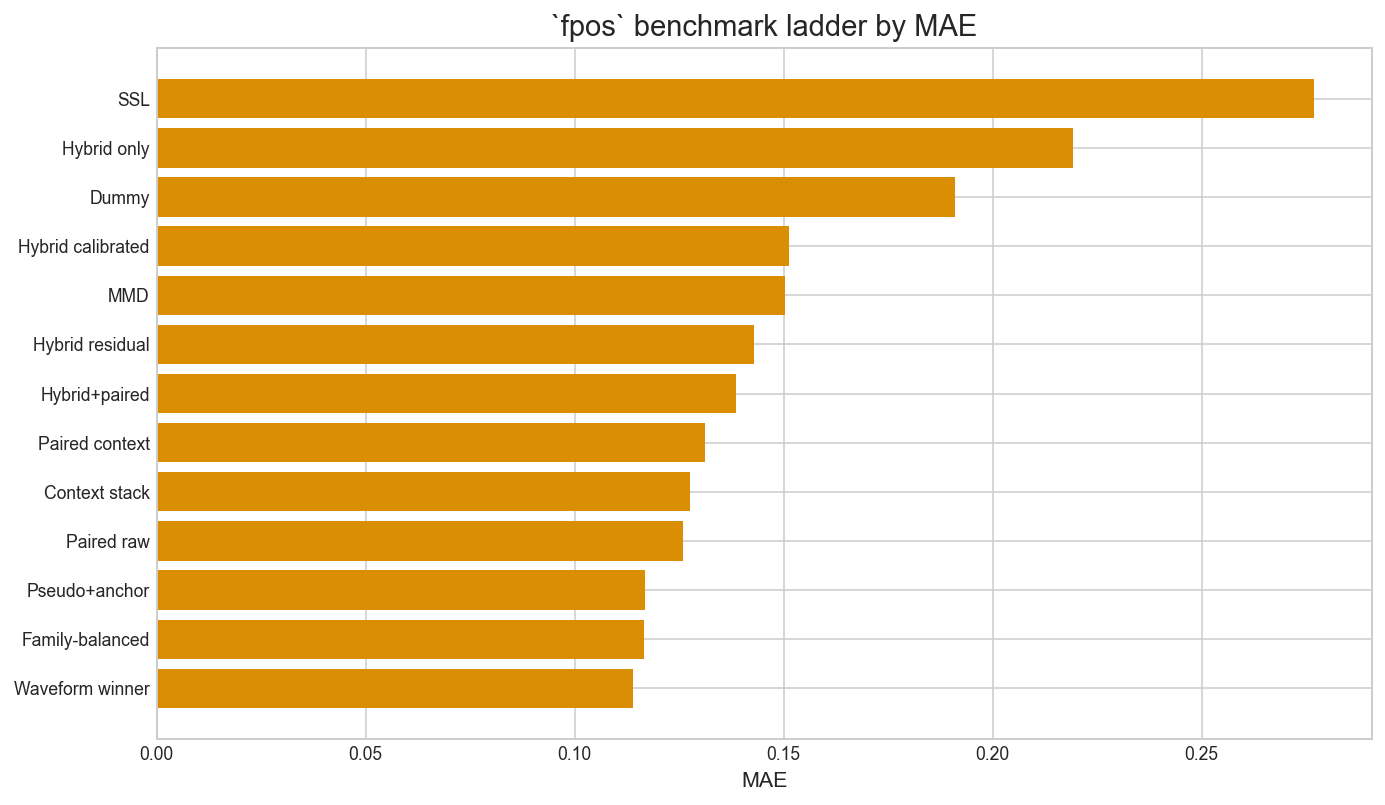

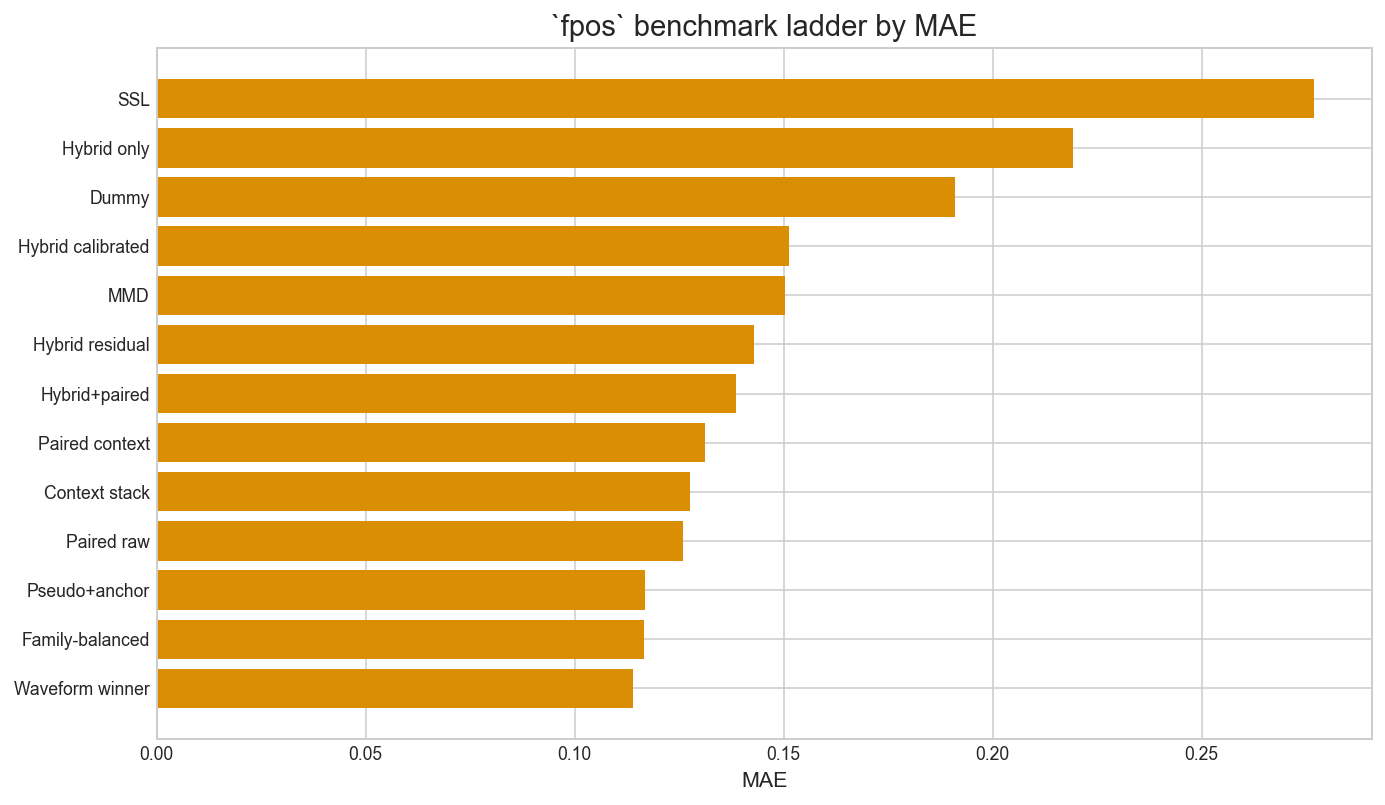

In [3]:
fig, _ = plot_benchmark_metric(benchmark, metric="mae", title="`fpos` benchmark ladder by MAE")
save_figure(fig, fig_dir, "fpos_benchmark_mae")
fig


In [4]:
winner_row = benchmark.sort_values("r2", ascending=False).iloc[0]
simple_row = benchmark.loc[benchmark["recipe_id"] == "fpos_hybrid_plus_paired"].iloc[0]
display(Markdown(
    f"""
## Main progression result

- The simple hybrid+paired baseline reaches **R² {simple_row['r2']:.4f}**.
- The final waveform winner reaches **R² {winner_row['r2']:.4f}**.
- That is a gain of **{winner_row['r2'] - simple_row['r2']:+.4f} R²** over the basic transfer recipe.
- The thesis should therefore present `fpos` as a sequence of answers: context, unlabeled target structure, robustness weighting, and waveform representation.
"""
))



## Main progression result

- The simple hybrid+paired baseline reaches **R² 0.3585**.
- The final waveform winner reaches **R² 0.5479**.
- That is a gain of **+0.1893 R²** over the basic transfer recipe.
- The thesis should therefore present `fpos` as a sequence of answers: context, unlabeled target structure, robustness weighting, and waveform representation.


## 2. Which ablation blocks mattered?

Each ablation group corresponds to one scientific question. The goal is not to show every run equally, but to make the causal story of the winner understandable.


In [5]:
display(ablation_winners)
save_table(ablation_winners, table_dir, "fpos_ablation_winners")


,ablation_group,best_label,best_recipe_id,best_r2,best_mae,notes
0,source_supervision,Paired-only raw,fpos_paired_raw,0.484615,0.125948,Small paired baseline
1,context,Context-first source stack,fpos_context_stack,0.500484,0.127567,Best pre-unlabeled context-first stack
2,unlabeled_paired_structure,Pre-waveform unlabeled structure,fpos_pre_waveform_unlabeled,0.533122,0.116937,Best positive result before waveform embedding
3,waveform_representation,Waveform winner,fpos_waveform_winner,0.547852,0.113970,Final `fpos` winner
4,robustness,Waveform winner,fpos_waveform_winner,0.547852,0.113970,Final `fpos` winner


PosixPath('/Users/paulruiz/Documents/Predicting_Good_Units/thesis/tables/04_fpos_model_progression/fpos_ablation_winners.csv')

In [6]:
for group_name in ["source_supervision", "context", "unlabeled_paired_structure", "waveform_representation", "robustness"]:
    bundle = build_ablation_bundle("fpos", group_name, "recording_disjoint_main")
    display(Markdown(f"### {group_name.replace('_', ' ').title()}"))
    display(bundle["benchmark"][["label", "mae", "r2", "notes"]])
    save_table(bundle["benchmark"], table_dir, f"fpos_ablation_{group_name}")


### Source Supervision

,label,mae,r2,notes
0,Dummy paired mean,0.191016,-0.000221,Sanity floor
0,Paired-only raw,0.125948,0.484615,Small paired baseline
0,Hybrid-only XGBoost,0.219198,-0.435141,Pure source failure baseline
0,Calibrated hybrid XGBoost,0.151354,0.245126,Simple calibrated transfer
0,Hybrid+paired basic XGBoost,0.138708,0.358539,Basic transfer baseline
0,Hybrid stack residual,0.142869,0.374912,First nonlinear stack


### Context

,label,mae,r2,notes
0,Paired-only raw,0.125948,0.484615,Small paired baseline
0,Paired-only context,0.131280,0.469508,Context-only target baseline
0,Context-first source stack,0.127567,0.500484,Best pre-unlabeled context-first stack


### Unlabeled Paired Structure

,label,mae,r2,notes
0,Context-first source stack,0.127567,0.500484,Best pre-unlabeled context-first stack
0,Pre-waveform unlabeled structure,0.116937,0.533122,Best positive result before waveform embedding
0,Family-balanced robustness,0.116678,0.511737,Robustness tradeoff variant


### Waveform Representation

,label,mae,r2,notes
0,Pre-waveform unlabeled structure,0.116937,0.533122,Best positive result before waveform embedding
0,Family-balanced robustness,0.116678,0.511737,Robustness tradeoff variant
0,Waveform winner,0.113970,0.547852,Final `fpos` winner


### Robustness

,label,mae,r2,notes
0,Pre-waveform unlabeled structure,0.116937,0.533122,Best positive result before waveform embedding
0,Family-balanced robustness,0.116678,0.511737,Robustness tradeoff variant
0,Waveform winner,0.113970,0.547852,Final `fpos` winner


## 3. Family and recording behavior of the main waves

The thesis should not claim improvement unless it can show that gains are broad. These summaries make it clear whether a new wave improved many recordings or only a handful.


,recipe_id,label,study_set,row_count,mae,rmse,r2,bias
0,fpos_paired_context,Paired-only context,PAIRED_BOYDEN,21,0.080373,0.095801,-0.157188,0.003837
1,fpos_paired_context,Paired-only context,PAIRED_CRCNS_HC1,9,0.162676,0.224957,0.401438,-0.083313
2,fpos_paired_context,Paired-only context,PAIRED_ENGLISH,44,0.185589,0.231378,0.375221,-0.039317
3,fpos_paired_context,Paired-only context,PAIRED_KAMPFF,6,0.088119,0.105418,0.778004,-0.088119
4,fpos_paired_context,Paired-only context,PAIRED_MEA64C_YGER,20,0.064072,0.086906,0.434650,-0.050447
5,fpos_context_stack,Context-first source stack,PAIRED_BOYDEN,21,0.073664,0.088640,0.009328,-0.002484
6,fpos_context_stack,Context-first source stack,PAIRED_CRCNS_HC1,9,0.162760,0.220289,0.426020,-0.070143
7,fpos_context_stack,Context-first source stack,PAIRED_ENGLISH,44,0.178670,0.223409,0.417517,-0.030592
8,fpos_context_stack,Context-first source stack,PAIRED_KAMPFF,6,0.100034,0.118447,0.719738,-0.100032
9,fpos_context_stack,Context-first source stack,PAIRED_MEA64C_YGER,20,0.064159,0.086991,0.433540,-0.045833


,recipe_id,label,recording_key,row_count,mae,rmse,r2,bias
0,fpos_paired_context,Paired-only context,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,10,0.106407,0.119421,-1.301811,0.070436
1,fpos_paired_context,Paired-only context,PAIRED_BOYDEN::paired_boyden32c::419_1_8,11,0.056707,0.067500,-0.020514,-0.056707
2,fpos_paired_context,Paired-only context,PAIRED_CRCNS_HC1::paired_crcns::d11221_d11221.001,1,0.376695,0.376695,NaN,-0.376695
3,fpos_paired_context,Paired-only context,PAIRED_CRCNS_HC1::paired_crcns::d11222_d11222.002,8,0.135923,0.197974,-0.124049,-0.046640
4,fpos_paired_context,Paired-only context,PAIRED_ENGLISH::paired_english::m139_200114_19...,3,0.223799,0.227852,-2.128321,-0.223799
5,fpos_paired_context,Paired-only context,PAIRED_ENGLISH::paired_english::m139_200114_22...,7,0.117592,0.133644,-0.845515,0.117592
6,fpos_paired_context,Paired-only context,PAIRED_ENGLISH::paired_english::m14_190326_155432,3,0.021276,0.023822,0.911736,0.002277
7,fpos_paired_context,Paired-only context,PAIRED_ENGLISH::paired_english::m15_190315_142...,6,0.337507,0.368810,-0.498656,-0.124643
8,fpos_paired_context,Paired-only context,PAIRED_ENGLISH::paired_english::m15_190315_152...,6,0.132453,0.189338,0.631044,-0.003961
9,fpos_paired_context,Paired-only context,PAIRED_ENGLISH::paired_english::m26_190524_100...,3,0.227851,0.277313,-1.703349,-0.227851


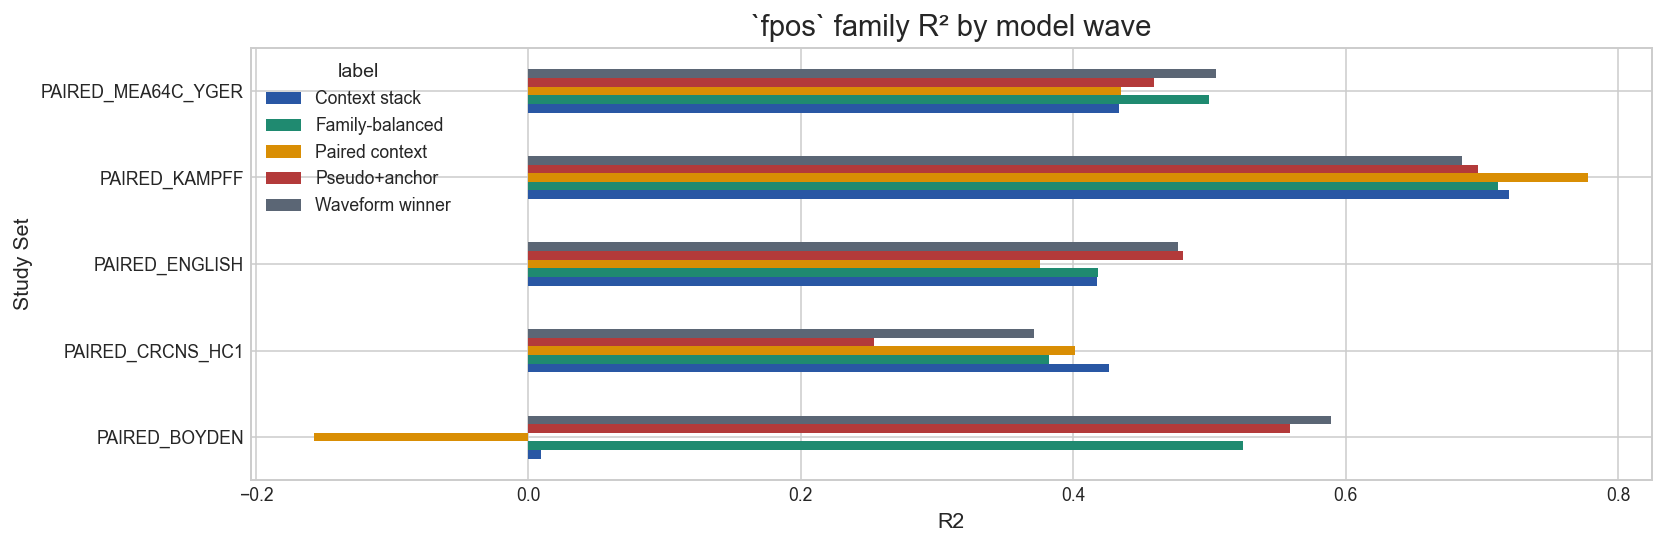

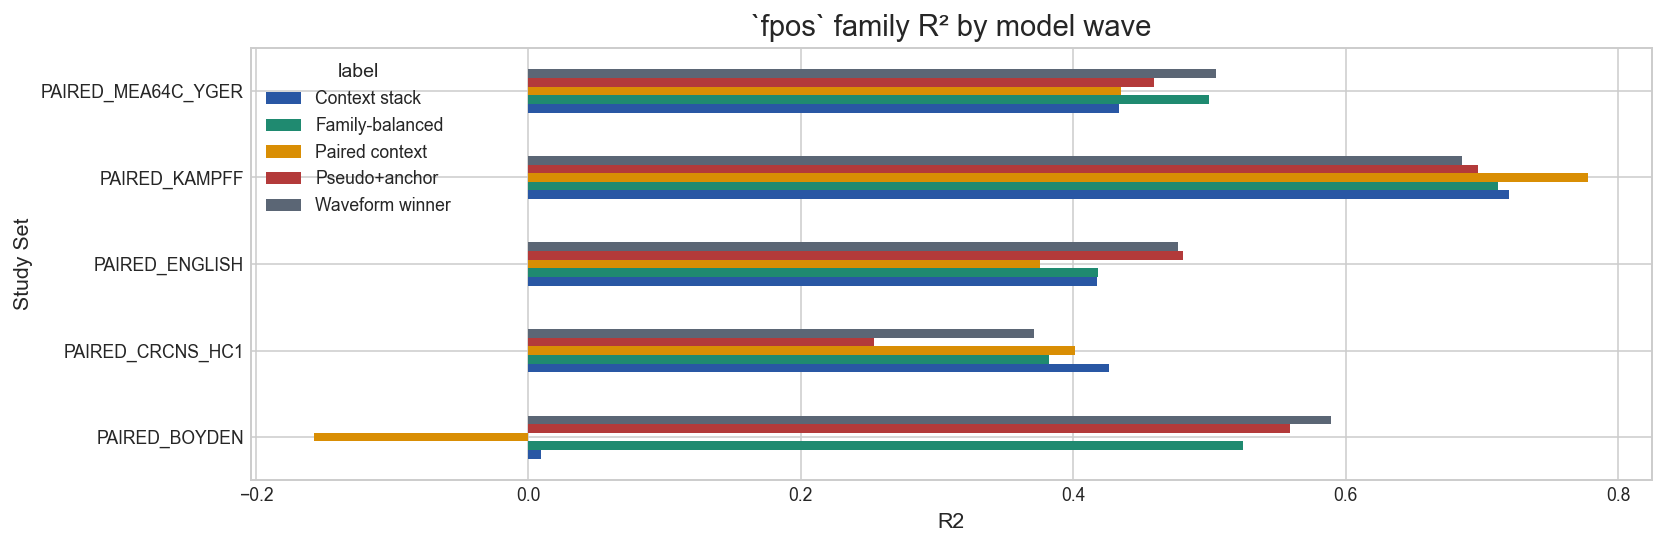

In [7]:
display(waves["family"])
display(waves["recording"].head(20))
save_table(waves["family"], table_dir, "fpos_family_wave_summary")
save_table(waves["recording"], table_dir, "fpos_recording_wave_summary")
fig, _, family_pivot = plot_group_metric(waves["family"], group_col="study_set", metric="r2", title="`fpos` family R² by model wave")
save_figure(fig, fig_dir, "fpos_family_r2_by_wave")
save_table(family_pivot, table_dir, "fpos_family_r2_pivot")
fig


,label,recording_key,r2
0,Waveform winner,PAIRED_MEA64C_YGER::paired_mea64c::20170622_pa...,0.789024
1,Waveform winner,PAIRED_KAMPFF::paired_kampff::c14,0.685079
2,Waveform winner,PAIRED_ENGLISH::paired_english::m15_190315_152...,0.531962
3,Waveform winner,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,0.458931
4,Waveform winner,PAIRED_ENGLISH::paired_english::m57_191105_160026,0.322278
5,Waveform winner,PAIRED_BOYDEN::paired_boyden32c::419_1_8,0.290007
6,Waveform winner,PAIRED_MEA64C_YGER::paired_mea64c::20170622_pa...,0.098752
7,Waveform winner,PAIRED_CRCNS_HC1::paired_crcns::d11222_d11222.002,0.079296
8,Waveform winner,PAIRED_ENGLISH::paired_english::m15_190315_142...,0.062911
9,Waveform winner,PAIRED_ENGLISH::paired_english::m57_191105_141906,-0.524826


,label,recording_key,r2
0,Waveform winner,PAIRED_ENGLISH::paired_english::m139_200114_19...,-3.175687
1,Waveform winner,PAIRED_ENGLISH::paired_english::m26_190524_100...,-1.146868
2,Waveform winner,PAIRED_ENGLISH::paired_english::m139_200114_22...,-1.013967
3,Waveform winner,PAIRED_ENGLISH::paired_english::m14_190326_155432,-0.597869
4,Waveform winner,PAIRED_ENGLISH::paired_english::m57_191105_141906,-0.524826
5,Waveform winner,PAIRED_ENGLISH::paired_english::m15_190315_142...,0.062911
6,Waveform winner,PAIRED_CRCNS_HC1::paired_crcns::d11222_d11222.002,0.079296
7,Waveform winner,PAIRED_MEA64C_YGER::paired_mea64c::20170622_pa...,0.098752
8,Waveform winner,PAIRED_BOYDEN::paired_boyden32c::419_1_8,0.290007
9,Waveform winner,PAIRED_ENGLISH::paired_english::m57_191105_160026,0.322278


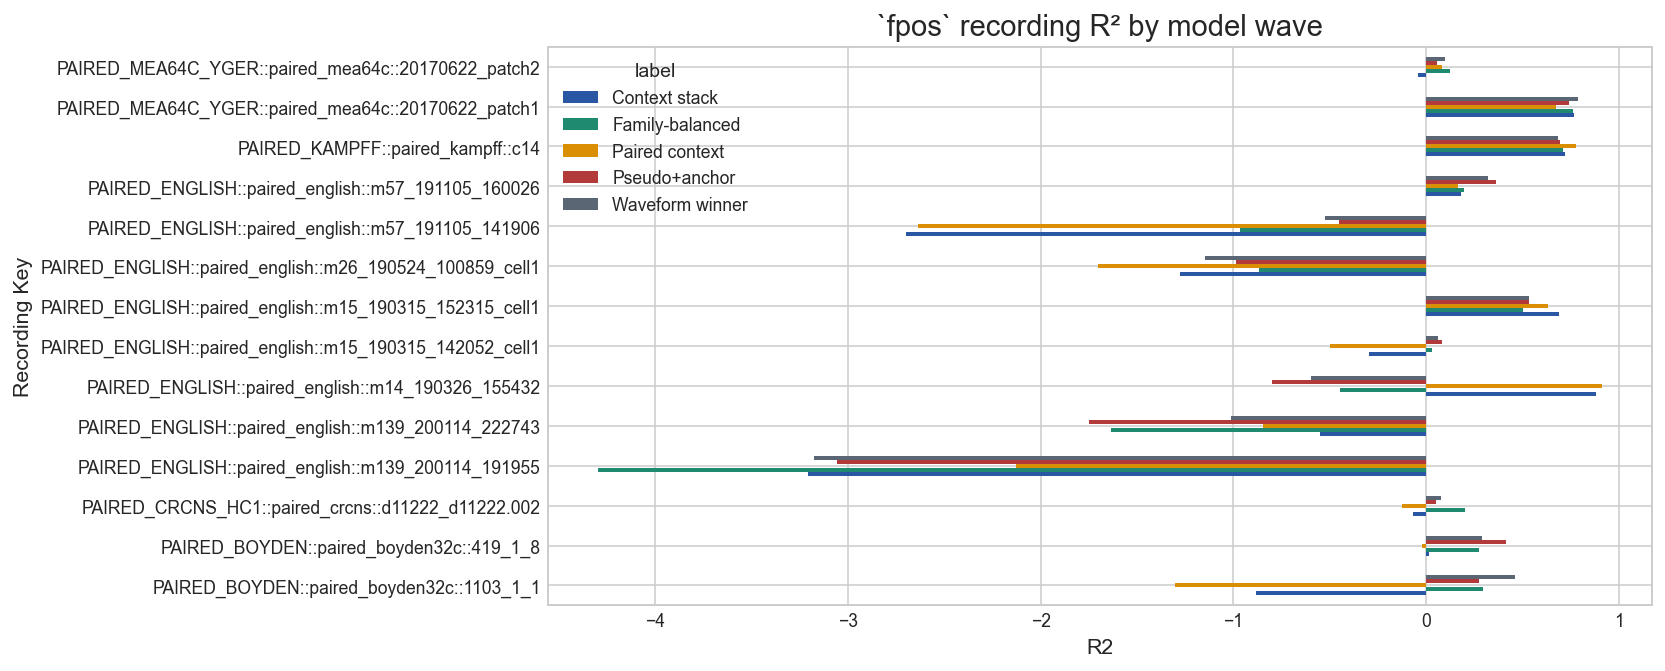

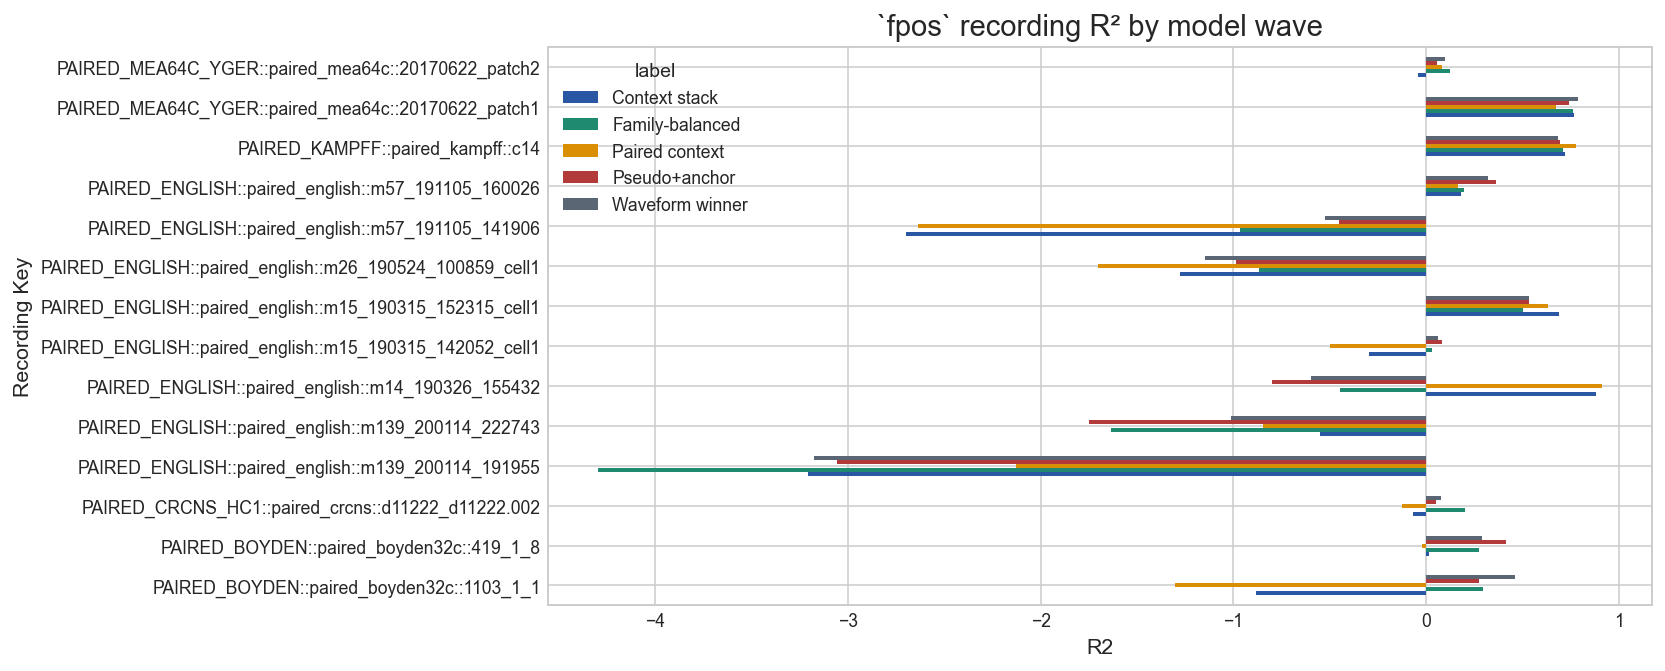

In [8]:
recording_mean = (
    waves["recording"]
    .groupby(["label", "recording_key"], as_index=False)["r2"]
    .mean()
)
top_rec, bottom_rec = build_extreme_groups_table(recording_mean[recording_mean["label"] == "Waveform winner"], group_col="recording_key", metric="r2", top_n=12)
display(top_rec)
display(bottom_rec)
save_table(top_rec, table_dir, "fpos_top_recordings")
save_table(bottom_rec, table_dir, "fpos_worst_recordings")
fig, _, rec_pivot = plot_group_metric(waves["recording"], group_col="recording_key", metric="r2", title="`fpos` recording R² by model wave")
save_figure(fig, fig_dir, "fpos_top_recording_r2_by_wave")
save_table(rec_pivot, table_dir, "fpos_recording_r2_pivot")
fig


## 4. Diagnostics for the final winner

The final model is not only a score. We also want a structural read: does it track the target at all, and what robustness cost does it pay under family-unseen transfer?


,protocol,target,variant_id,family,backend,row_uid,recording_key,study_set,true,pred,abs_error,recipe_id,label,residual
0,main,fpos,wf_embed_anchor_stack_xgboost,signal_embedding_stack,xgboost_default,PAIRED_BOYDEN::paired_boyden32c::1103_1_1::Iro...,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,PAIRED_BOYDEN,0.113636,0.149459,0.035823,fpos_waveform_winner,Waveform winner,0.035823
1,main,fpos,wf_embed_anchor_stack_xgboost,signal_embedding_stack,xgboost_default,PAIRED_BOYDEN::paired_boyden32c::1103_1_1::JRC...,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,PAIRED_BOYDEN,0.261381,0.291526,0.030145,fpos_waveform_winner,Waveform winner,0.030145
2,main,fpos,wf_embed_anchor_stack_xgboost,signal_embedding_stack,xgboost_default,PAIRED_BOYDEN::paired_boyden32c::1103_1_1::Kil...,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,PAIRED_BOYDEN,0.112410,0.179908,0.067498,fpos_waveform_winner,Waveform winner,0.067498
3,main,fpos,wf_embed_anchor_stack_xgboost,signal_embedding_stack,xgboost_default,PAIRED_BOYDEN::paired_boyden32c::1103_1_1::Kil...,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,PAIRED_BOYDEN,0.170663,0.201796,0.031133,fpos_waveform_winner,Waveform winner,0.031133
4,main,fpos,wf_embed_anchor_stack_xgboost,signal_embedding_stack,xgboost_default,PAIRED_BOYDEN::paired_boyden32c::1103_1_1::Kil...,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,PAIRED_BOYDEN,0.333333,0.210007,0.123326,fpos_waveform_winner,Waveform winner,-0.123326
5,main,fpos,wf_embed_anchor_stack_xgboost,signal_embedding_stack,xgboost_default,PAIRED_BOYDEN::paired_boyden32c::1103_1_1::Kil...,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,PAIRED_BOYDEN,0.158784,0.110351,0.048432,fpos_waveform_winner,Waveform winner,-0.048432
6,main,fpos,wf_embed_anchor_stack_xgboost,signal_embedding_stack,xgboost_default,PAIRED_BOYDEN::paired_boyden32c::1103_1_1::Klu...,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,PAIRED_BOYDEN,0.156687,0.217810,0.061123,fpos_waveform_winner,Waveform winner,0.061123
7,main,fpos,wf_embed_anchor_stack_xgboost,signal_embedding_stack,xgboost_default,PAIRED_BOYDEN::paired_boyden32c::1103_1_1::Mou...,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,PAIRED_BOYDEN,0.305322,0.316286,0.010964,fpos_waveform_winner,Waveform winner,0.010964
8,main,fpos,wf_embed_anchor_stack_xgboost,signal_embedding_stack,xgboost_default,PAIRED_BOYDEN::paired_boyden32c::1103_1_1::Spy...,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,PAIRED_BOYDEN,0.122581,0.183903,0.061323,fpos_waveform_winner,Waveform winner,0.061323
9,main,fpos,wf_embed_anchor_stack_xgboost,signal_embedding_stack,xgboost_default,PAIRED_BOYDEN::paired_boyden32c::1103_1_1::Tri...,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,PAIRED_BOYDEN,0.261327,0.286514,0.025187,fpos_waveform_winner,Waveform winner,0.025187


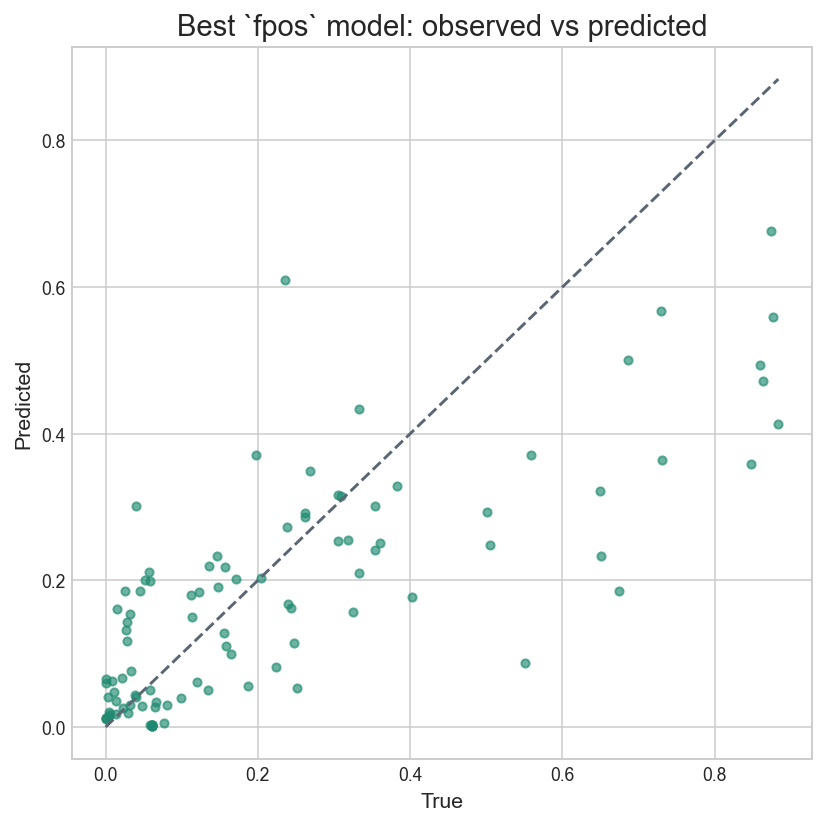

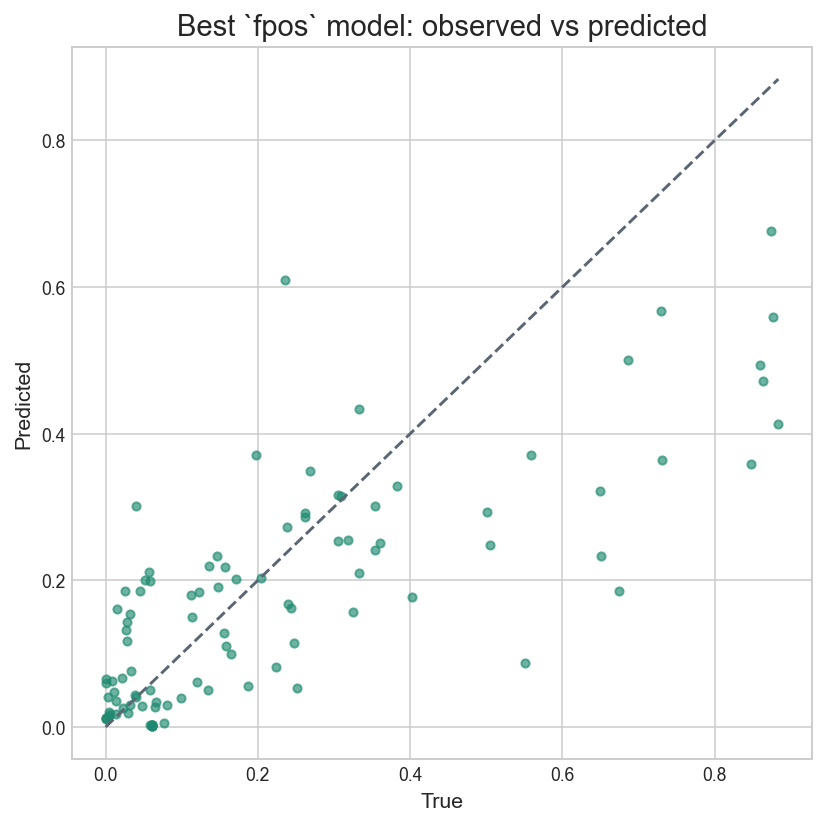

In [9]:
winner_predictions = winner_diag["predictions"]
display(winner_predictions.head(20))
fig, _ = plot_prediction_scatter(winner_predictions, title="Best `fpos` model: observed vs predicted")
save_figure(fig, fig_dir, "fpos_winner_prediction_scatter")
fig


In [10]:
lofo_companion = limitations.lofo_aggregate[limitations.lofo_aggregate["variant_id"].isin(["reference_anchor_stack_xgboost", "family_balanced_strong_xgboost", "wf_embed_anchor_stack_xgboost"])].copy()
display(lofo_companion)
save_table(lofo_companion, table_dir, "fpos_family_held_out_companion")


,variant_id,macro_mae,macro_r2,weighted_mae,weighted_r2,worst_family_r2,best_family_r2
0,reference_anchor_stack_xgboost,0.125455,0.452724,0.131071,0.423981,0.293988,0.546858
1,wf_embed_anchor_stack_xgboost,0.122189,0.438568,0.126716,0.411617,0.148179,0.695184


PosixPath('/Users/paulruiz/Documents/Predicting_Good_Units/thesis/tables/04_fpos_model_progression/fpos_family_held_out_companion.csv')

In [11]:
display(Markdown(
    f"""
## Key takeaways

- `fpos` improves in a staged way: **context -> unlabeled paired structure -> robustness weighting -> waveform representation**.
- The final winner has mean absolute error **{winner_diag['mae']:.4f}** on the saved holdout predictions and a true/predicted correlation of **{winner_diag['correlation']:.3f}**.
- The family-held-out companion table is essential: the waveform winner is the headline model for the main benchmark, but not the safest unseen-family model.
"""
))



## Key takeaways

- `fpos` improves in a staged way: **context -> unlabeled paired structure -> robustness weighting -> waveform representation**.
- The final winner has mean absolute error **0.1140** on the saved holdout predictions and a true/predicted correlation of **0.778**.
- The family-held-out companion table is essential: the waveform winner is the headline model for the main benchmark, but not the safest unseen-family model.
